
# No. 1

**Nama:** Winston Octavianus Sugih

**NIM:** 2802403776

**Link video presentasi:** https://drive.google.com/file/d/1OubCbkonsvZv8ElaMd6oy8sQqzdvluGd/view?usp=sharing



## 1. Import Library


In [ ]:
import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)



## 2. Konfigurasi Eksperimen


In [ ]:
import os

BASE_DIR = "/content/drive/MyDrive/DATASET"

DATA_FILES = {
    "AAPL": os.path.join(BASE_DIR, "AAPL.csv"),
    "AMD": os.path.join(BASE_DIR, "AMD.csv")
}

WINDOW_SIZE = 5
HORIZON = 1

TRAIN_RATIO = 0.90

BASELINE_EPOCHS = 25
MODIFIED_EPOCHS = 80
BATCH_SIZE = 32


## 3. Functions


In [ ]:
def find_file(filepath):
    if os.path.exists(filepath):
        return filepath

    raise FileNotFoundError(
        f"File not found: {filepath}\n"
    )


def load_stock_data(filepath):
    path = find_file(filepath)
    df = pd.read_csv(path)

    # Cek apakah kolom yang dibutuhkan tersedia
    required_columns = ["Date", "Close"]
    missing_columns = [col for col in required_columns if col not in df.columns]

    if missing_columns:
        raise ValueError(
            f"Kolom berikut tidak ditemukan di dataset: {missing_columns}. "
            f"Kolom yang tersedia: {list(df.columns)}"
        )

    # Ambil kolom yang diminta soal
    df = df[["Date", "Close"]].copy()

    # Ubah Date ke datetime dan urutkan berdasarkan tanggal
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)

    # Pastikan Close bertipe numerik
    df["Close"] = pd.to_numeric(df["Close"], errors="coerce")

    return df


def show_basic_eda(df, ticker):
    print(f"EDA untuk {ticker}")
    print("Jumlah baris dan kolom:", df.shape)
    print("\nLima data pertama:")
    display(df.head())
    print("\nLima data terakhir:")
    display(df.tail())
    print("\nInformasi data:")
    print(df.info())
    print("\nMissing value:")
    print(df.isna().sum())
    print("\nStatistik deskriptif Close:")
    display(df["Close"].describe())
    print("\nRentang tanggal:")
    print("Tanggal awal :", df["Date"].min())
    print("Tanggal akhir:", df["Date"].max())


def plot_close_price(df, ticker):
    plt.figure(figsize=(12, 5))
    plt.plot(df["Date"], df["Close"])
    plt.title(f"Harga Close Saham {ticker}")
    plt.xlabel("Date")
    plt.ylabel("Close Price")
    plt.grid(True)
    plt.show()


def create_windows(series, window_size=5, horizon=1):
    X, y = [], []

    for i in range(len(series) - window_size - horizon + 1):
        X.append(series[i:i + window_size])
        y.append(series[i + window_size + horizon - 1])

    X = np.array(X)
    y = np.array(y)

    return X, y


def chronological_train_val_split(X, y, train_ratio=0.90):
    split_idx = int(len(X) * train_ratio)

    X_train = X[:split_idx]
    y_train = y[:split_idx]

    X_val = X[split_idx:]
    y_val = y[split_idx:]

    return X_train, X_val, y_train, y_val


def create_test_windows(train_scaled, test_scaled, window_size=5, horizon=1):
    combined = np.concatenate([train_scaled[-window_size:], test_scaled], axis=0)
    X_test, y_test = create_windows(combined, window_size=window_size, horizon=horizon)
    return X_test, y_test


def inverse_transform_1d(scaler, values):
    values = np.asarray(values).reshape(-1, 1)
    return scaler.inverse_transform(values).reshape(-1)


def calculate_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    return {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE (%)": mape
    }


## 4. Loading Data dan EDA



EDA untuk AAPL
Jumlah baris dan kolom: (9909, 2)

Lima data pertama:


,Date,Close
0,1980-12-12,0.513393
1,1980-12-15,0.486607
2,1980-12-16,0.450893
3,1980-12-17,0.462054
4,1980-12-18,0.475446



Lima data terakhir:


,Date,Close
9904,2020-03-26,258.440002
9905,2020-03-27,247.740005
9906,2020-03-30,254.809998
9907,2020-03-31,254.289993
9908,2020-04-01,240.910004



Informasi data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9909 entries, 0 to 9908
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    9909 non-null   datetime64[ns]
 1   Close   9909 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 155.0 KB
None

Missing value:
Date     0
Close    0
dtype: int64

Statistik deskriptif Close:


,Close
count,9909.000000
mean,32.618030
std,58.471899
min,0.196429
25%,1.071429
50%,1.732143
75%,35.761429
max,327.200012



Rentang tanggal:
Tanggal awal : 1980-12-12 00:00:00
Tanggal akhir: 2020-04-01 00:00:00


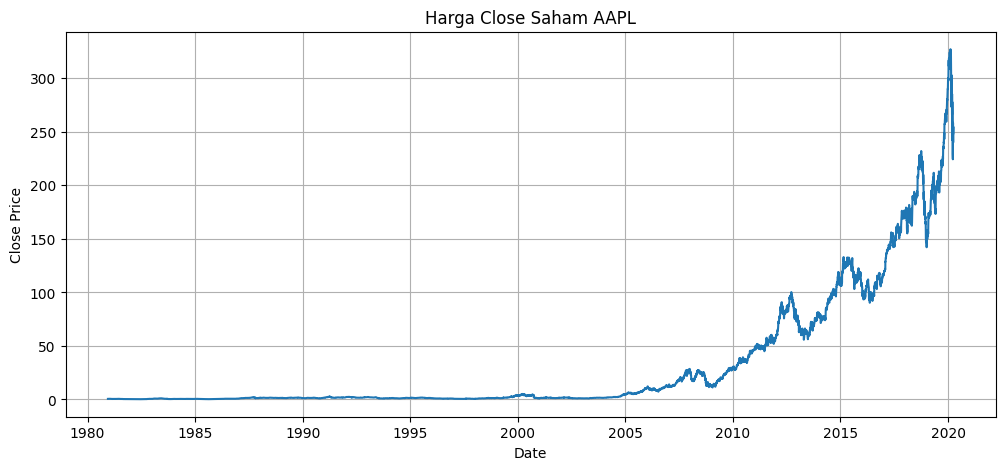

EDA untuk AMD
Jumlah baris dan kolom: (10098, 2)

Lima data pertama:


,Date,Close
0,1980-03-17,3.145833
1,1980-03-18,3.031250
2,1980-03-19,3.041667
3,1980-03-20,3.010417
4,1980-03-21,2.916667



Lima data terakhir:


,Date,Close
10093,2020-03-26,47.500000
10094,2020-03-27,46.580002
10095,2020-03-30,47.860001
10096,2020-03-31,45.480000
10097,2020-04-01,43.660000



Informasi data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10098 entries, 0 to 10097
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    10098 non-null  datetime64[ns]
 1   Close   10098 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 157.9 KB
None

Missing value:
Date     0
Close    0
dtype: int64

Statistik deskriptif Close:


,Close
count,10098.000000
mean,11.210802
std,8.283645
min,1.620000
25%,4.937500
50%,9.062500
75%,14.707500
max,58.900002



Rentang tanggal:
Tanggal awal : 1980-03-17 00:00:00
Tanggal akhir: 2020-04-01 00:00:00


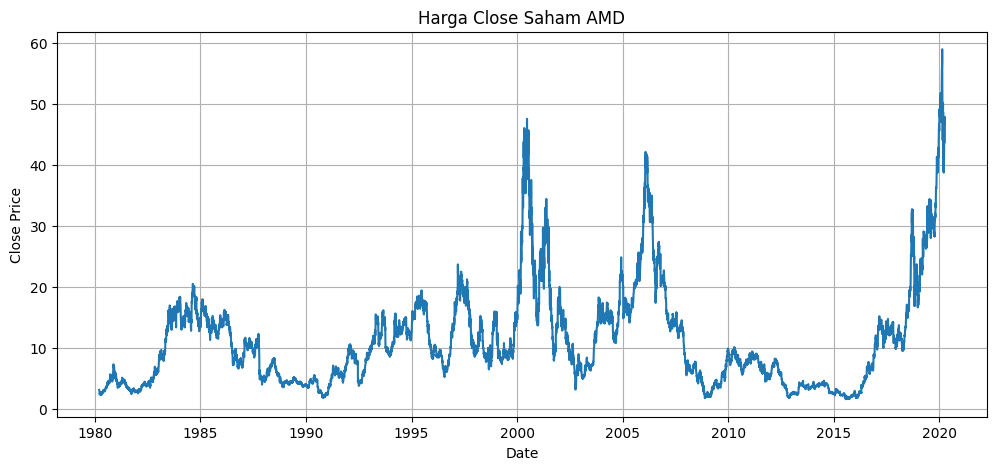

In [ ]:
stock_data = {}

for ticker, filename in DATA_FILES.items():
    df = load_stock_data(filename)
    stock_data[ticker] = df

    show_basic_eda(df, ticker)
    plot_close_price(df, ticker)



## 5. Preprocessing dan Time Series Split

In [ ]:
def preprocess_stock_data(df, ticker):
    df = df.dropna(subset=["Date", "Close"]).copy()
    df = df.sort_values("Date").reset_index(drop=True)

    max_date = df["Date"].max()
    test_start_date = max_date - pd.DateOffset(years=1)

    train_raw = df[df["Date"] < test_start_date].copy()
    test_raw = df[df["Date"] >= test_start_date].copy()

    scaler = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(train_raw[["Close"]])
    test_scaled = scaler.transform(test_raw[["Close"]])

    X_train_all, y_train_all = create_windows(
        train_scaled,
        window_size=WINDOW_SIZE,
        horizon=HORIZON
    )

    X_train, X_val, y_train, y_val = chronological_train_val_split(
        X_train_all,
        y_train_all,
        train_ratio=TRAIN_RATIO
    )

    X_test, y_test = create_test_windows(
        train_scaled,
        test_scaled,
        window_size=WINDOW_SIZE,
        horizon=HORIZON
    )

    print(f"Preprocessing Summary untuk {ticker}")
    print("Tanggal awal data     :", df["Date"].min().date())
    print("Tanggal akhir data    :", df["Date"].max().date())
    print("Tanggal awal test     :", test_start_date.date())
    print("Jumlah data train raw :", len(train_raw))
    print("Jumlah data test raw  :", len(test_raw))
    print("X_train shape         :", X_train.shape)
    print("y_train shape         :", y_train.shape)
    print("X_val shape           :", X_val.shape)
    print("y_val shape           :", y_val.shape)
    print("X_test shape          :", X_test.shape)
    print("y_test shape          :", y_test.shape)

    return {
        "df": df,
        "train_raw": train_raw,
        "test_raw": test_raw,
        "scaler": scaler,
        "X_train": X_train,
        "y_train": y_train,
        "X_val": X_val,
        "y_val": y_val,
        "X_test": X_test,
        "y_test": y_test
    }


processed_data = {}

for ticker, df in stock_data.items():
    processed_data[ticker] = preprocess_stock_data(df, ticker)


Preprocessing Summary untuk AAPL
Tanggal awal data     : 1980-12-12
Tanggal akhir data    : 2020-04-01
Tanggal awal test     : 2019-04-01
Jumlah data train raw : 9655
Jumlah data test raw  : 254
X_train shape         : (8685, 5, 1)
y_train shape         : (8685, 1)
X_val shape           : (965, 5, 1)
y_val shape           : (965, 1)
X_test shape          : (254, 5, 1)
y_test shape          : (254, 1)
Preprocessing Summary untuk AMD
Tanggal awal data     : 1980-03-17
Tanggal akhir data    : 2020-04-01
Tanggal awal test     : 2019-04-01
Jumlah data train raw : 9844
Jumlah data test raw  : 254
X_train shape         : (8855, 5, 1)
y_train shape         : (8855, 1)
X_val shape           : (984, 5, 1)
y_val shape           : (984, 1)
X_test shape          : (254, 5, 1)
y_test shape          : (254, 1)



## 6. Baseline Model LSTM


In [ ]:
def build_baseline_model(window_size=5):
    model = Sequential([
        Input(shape=(window_size, 1)),
        LSTM(units=50, activation="relu"),
        Dense(units=1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    return model


baseline_models = {}

for ticker in DATA_FILES.keys():
    print(f"Baseline Model Summary untuk {ticker}")

    model = build_baseline_model(WINDOW_SIZE)
    model.summary()
    baseline_models[ticker] = model


Baseline Model Summary untuk AAPL


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

...

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)


## 7. Training Baseline Model


In [ ]:
baseline_histories = {}

for ticker, data in processed_data.items():
    print(f"Training Baseline Model untuk {ticker}")

    model = baseline_models[ticker]

    history = model.fit(
        data["X_train"],
        data["y_train"],
        validation_data=(data["X_val"], data["y_val"]),
        epochs=BASELINE_EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1
    )

    baseline_histories[ticker] = history


Training Baseline Model untuk AAPL
Epoch 1/25
272/272 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0011 - mae: 0.0112 - val_loss: 2.9555e-04 - val_mae: 0.0126
Epoch 2/25
272/272 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 1.2926e-05 - mae: 0.0019 - val_loss: 2.7849e-04 - val_mae: 0.0116
Epoch 3/25
272/272 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1.1771e-05 - mae: 0.0018 - val_loss: 3.0805e-04 - val_mae: 0.0120
Epoch 4/25
272/272 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 1.1901e-05 - mae: 0.0018 - val_loss: 3.0981e-04 - val_mae: 0.0120
Epoch 5/25
272/272 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.2217e-05 - mae: 0.0019 - val_loss: 3.0972e-04 - val_mae: 0.0120
Epoch 6/25
272/272 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.2379e-05 - mae: 0.0020 - val_loss: 3.0471e-04 - val_mae: 0.0120
Epoch 7/25
272/272 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.2403e-05 - mae: 0.0020 - val_loss: 3.0934e-04 - val_mae: 0.0122
Epoch 8/25
272/272 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.2365e-05 - mae: 0.0020 - 

## 8. Modifikasi Arsitektur LSTM

Arsitektur baseline hanya terdiri dari satu layer LSTM 50 unit dan satu Dense, sehingga kapasitasnya terbatas untuk menangkap pola harga yang kompleks. Karena itu arsitektur dimodifikasi, dan desainnya sengaja disesuaikan dengan karakteristik tiap saham yang terlihat dari hasil EDA.

Dari EDA terlihat harga AAPL jauh lebih tinggi dan lebih fluktuatif, dengan standar deviasi sekitar 58 dan harga maksimum sekitar 327. Sebaliknya AMD jauh lebih rendah dan lebih stabil, dengan standar deviasi sekitar 8 dan harga maksimum sekitar 59. Perbedaan karakteristik inilah yang mendasari pemilihan arsitektur yang berbeda untuk kedua saham.

Untuk AAPL dipakai model yang lebih besar. Alasan tiap komponennya:
- Dua layer LSTM bertumpuk (128 lalu 64 unit) untuk menangkap pola temporal bertingkat dan memberi kapasitas representasi lebih besar pada data yang fluktuatif.
- Dropout 0.10 sebagai regularisasi untuk mengurangi risiko overfitting setelah kapasitas model dinaikkan.
- BatchNormalization untuk menstabilkan distribusi aktivasi antar layer, supaya training pada data berentang harga besar lebih stabil dan cepat konvergen.
- Hidden Dense 32 untuk menambah kemampuan memetakan fitur dari LSTM ke output harga.
- EarlyStopping dengan patience 15 dan ReduceLROnPlateau, supaya model dapat dilatih lebih lama tanpa overfitting dan learning rate diturunkan otomatis ketika validation loss berhenti membaik.

Untuk AMD dipakai model yang lebih ringan, yaitu LSTM 64 lalu 32 unit dengan Dropout 0.05, tanpa BatchNormalization dan tanpa hidden Dense. Alasannya karena pola harga AMD lebih stabil, sehingga model yang terlalu besar justru berisiko overfitting. Hal ini terlihat pada percobaan awal, di mana arsitektur yang terlalu kompleks untuk AMD menghasilkan MAPE yang jauh lebih buruk dibanding model yang lebih sederhana.

In [ ]:
def build_modified_model(window_size=5, ticker="AAPL"):
    if ticker == "AAPL":
        model = Sequential([
            Input(shape=(window_size, 1)),
            LSTM(units=128, activation="relu", return_sequences=True),
            Dropout(0.10),
            LSTM(units=64, activation="relu"),
            BatchNormalization(),
            Dense(units=32, activation="relu"),
            Dense(units=1)
        ])
        optimizer = Adam(learning_rate=0.001)

    else:  # AMD
        model = Sequential([
            Input(shape=(window_size, 1)),
            LSTM(units=64, activation="relu", return_sequences=True),
            Dropout(0.05),
            LSTM(units=32, activation="relu"),
            Dense(units=1)
        ])
        optimizer = Adam(learning_rate=0.001)

    model.compile(optimizer=optimizer, loss="mse", metrics=["mae"])
    return model


modified_models = {}

for ticker in DATA_FILES.keys():
    print(f"Modified Model Summary untuk {ticker}")

    model = build_modified_model(WINDOW_SIZE, ticker=ticker)
    model.summary()
    modified_models[ticker] = model


Modified Model Summary untuk AAPL


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 5, 128)         │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,337 (462.25 KB)

 Trainable params: 118,209 (461.75 KB)

...

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 5, 64)          │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)


## 9. Training Modified Model

In [ ]:
modified_models = {}
modified_histories = {}

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=6,
        min_lr=1e-6
    )
]

for ticker, data in processed_data.items():
    print(f"Training Modified Model untuk {ticker}")

    model = build_modified_model(WINDOW_SIZE, ticker=ticker)
    model.summary()

    history = model.fit(
        data["X_train"],
        data["y_train"],
        validation_data=(data["X_val"], data["y_val"]),
        epochs=MODIFIED_EPOCHS,
        batch_size=32,
        callbacks=callbacks,
        verbose=1
    )

    modified_models[ticker] = model
    modified_histories[ticker] = history

Training Modified Model untuk AAPL


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 5, 128)         │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,337 (462.25 KB)

 Trainable params: 118,209 (461.75 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 5, 64)          │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/80
277/277 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0038 - mae: 0.0284 - val_loss: 4.8476e-04 - val_mae: 0.0166 - learning_rate: 0.0010
Epoch 2/80
277/277 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 3.9759e-04 - mae: 0.0128 - val_loss: 4.1034e-04 - val_mae: 0.0143 - learning_rate: 0.0010
Epoch 3/80
277/277 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 3.6700e-04 - mae: 0.0123 - val_loss: 4.1633e-04 - val_mae: 0.0142 - learning_rate: 0.0010
Epoch 4/80
277/277 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 3.7433e-04 - mae: 0.0126 - val_loss: 4.3646e-04 - val_mae: 0.0159 - learning_rate: 0.0010
Epoch 5/80
277/277 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 3.3904e-04 - mae: 0.0120 - val_loss: 4.1406e-04 - val_mae: 0.0155 - learning_rate: 0.0010
Epoch 6/80
277/277 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 3.2538e-04 - mae: 0.0117 - val_loss: 3.3614e-04 - val_mae: 0.0134 - learning_rate: 0.0010
Epoch 7/80
277/277 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 2.8137e-04 - mae: 0.0106 - val_loss: 2.75


## 10. Visualisasi Training Loss

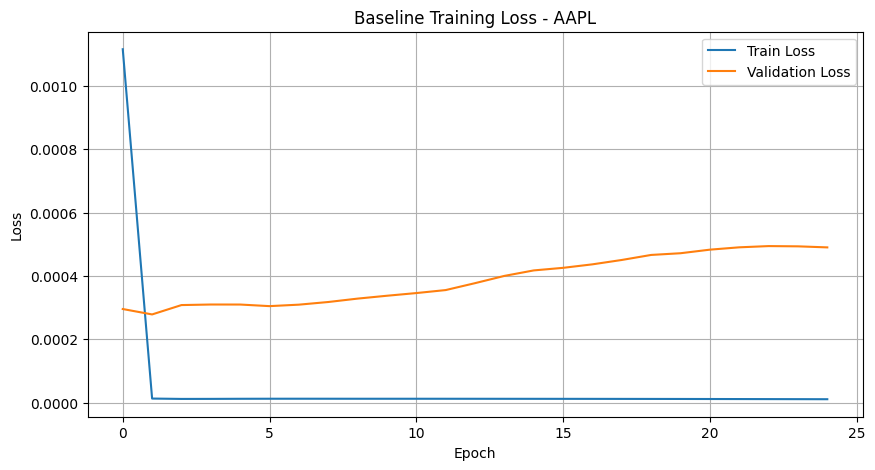

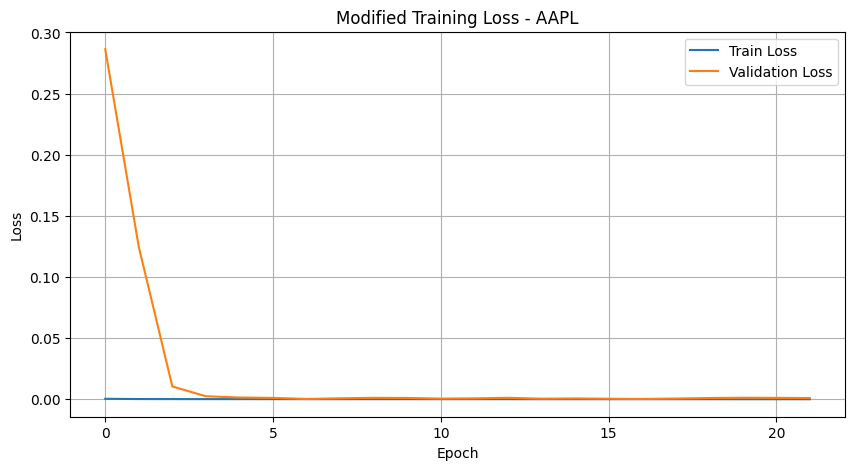

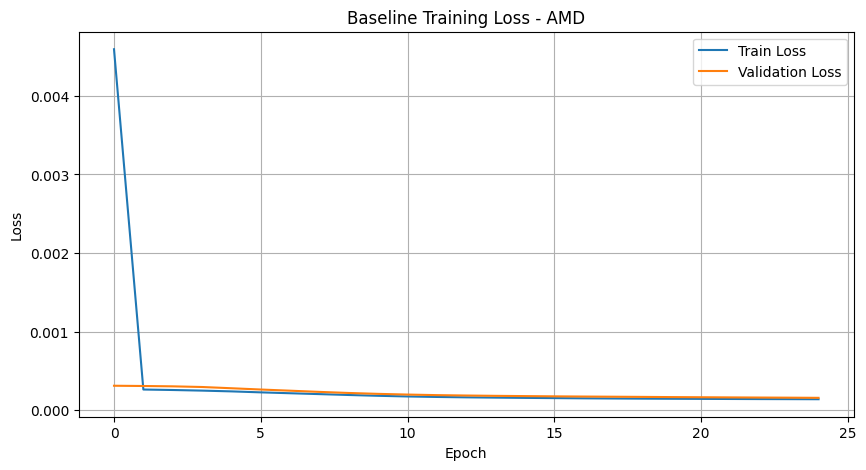

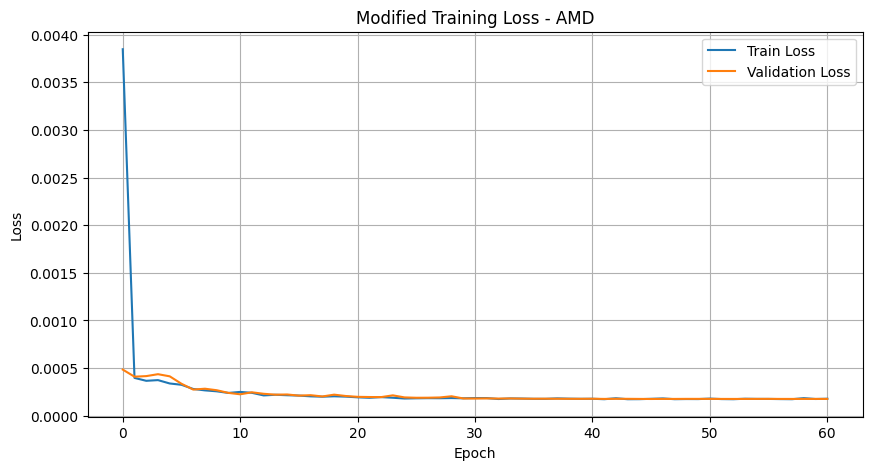

In [ ]:
def plot_training_history(history, title):
    plt.figure(figsize=(10, 5))
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()


for ticker in DATA_FILES.keys():
    plot_training_history(
        baseline_histories[ticker],
        f"Baseline Training Loss - {ticker}"
    )

    plot_training_history(
        modified_histories[ticker],
        f"Modified Training Loss - {ticker}"
    )



## 11. Evaluasi pada Test Set


In [ ]:
all_results = []
predictions = {}

for ticker, data in processed_data.items():
    scaler = data["scaler"]

    X_test = data["X_test"]
    y_test_scaled = data["y_test"]

    y_test_actual = inverse_transform_1d(scaler, y_test_scaled)

    # Baseline prediction
    baseline_pred_scaled = baseline_models[ticker].predict(X_test)
    baseline_pred_actual = inverse_transform_1d(scaler, baseline_pred_scaled)
    baseline_metrics = calculate_metrics(y_test_actual, baseline_pred_actual)

    all_results.append({
        "Ticker": ticker,
        "Model": "Baseline LSTM",
        **baseline_metrics
    })

    # Modified prediction
    modified_pred_scaled = modified_models[ticker].predict(X_test)
    modified_pred_actual = inverse_transform_1d(scaler, modified_pred_scaled)
    modified_metrics = calculate_metrics(y_test_actual, modified_pred_actual)

    all_results.append({
        "Ticker": ticker,
        "Model": "Modified LSTM",
        **modified_metrics
    })

    predictions[ticker] = {
        "actual": y_test_actual,
        "baseline": baseline_pred_actual,
        "modified": modified_pred_actual
    }

results_df = pd.DataFrame(all_results)
display(results_df)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step


,Ticker,Model,RMSE,MAE,MAPE (%)
0,AAPL,Baseline LSTM,27.862991,20.933240,7.956877
1,AAPL,Modified LSTM,8.508655,6.926948,2.825850
2,AMD,Baseline LSTM,1.444797,1.015776,2.725393
3,AMD,Modified LSTM,1.350479,0.903443,2.434595



## 12. Plot Actual vs Predicted


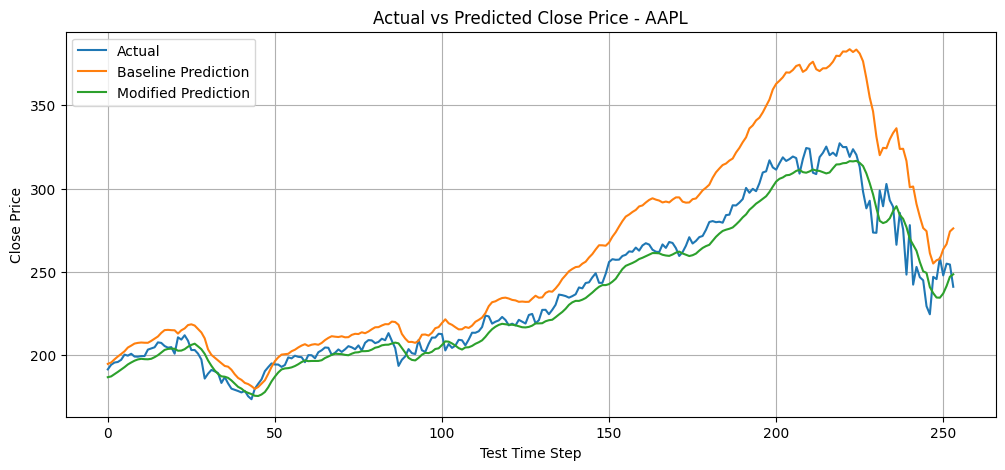

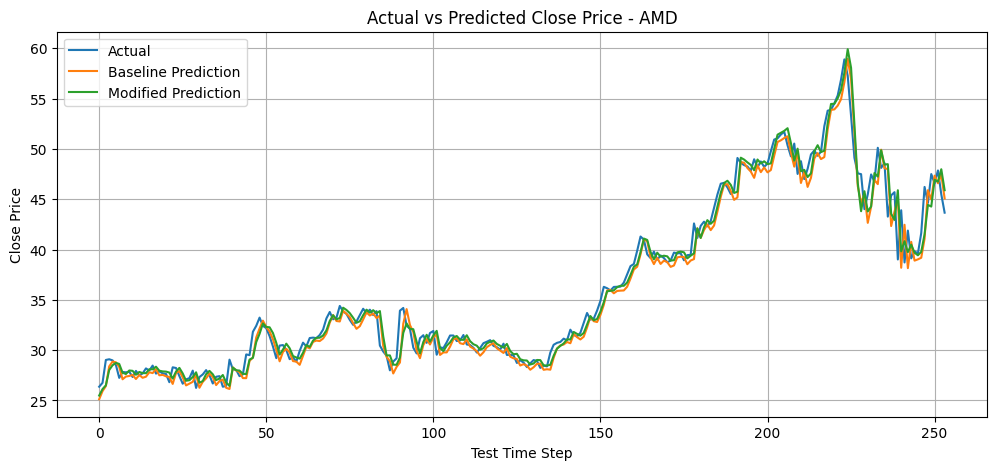

In [ ]:
def plot_predictions(ticker, preds):
    plt.figure(figsize=(12, 5))
    plt.plot(preds["actual"], label="Actual")
    plt.plot(preds["baseline"], label="Baseline Prediction")
    plt.plot(preds["modified"], label="Modified Prediction")
    plt.title(f"Actual vs Predicted Close Price - {ticker}")
    plt.xlabel("Test Time Step")
    plt.ylabel("Close Price")
    plt.legend()
    plt.grid(True)
    plt.show()


for ticker, preds in predictions.items():
    plot_predictions(ticker, preds)



## 13. Analisis Hasil


In [ ]:
for ticker in DATA_FILES.keys():
    ticker_result = results_df[results_df["Ticker"] == ticker].copy()
    best_rmse_model = ticker_result.sort_values("RMSE").iloc[0]
    best_mae_model = ticker_result.sort_values("MAE").iloc[0]
    best_mape_model = ticker_result.sort_values("MAPE (%)").iloc[0]

    print(f"Analisis untuk {ticker} :")
    print(f"Model terbaik berdasarkan RMSE : {best_rmse_model['Model']} dengan RMSE {best_rmse_model['RMSE']:.4f}")
    print(f"Model terbaik berdasarkan MAE  : {best_mae_model['Model']} dengan MAE {best_mae_model['MAE']:.4f}")
    print(f"Model terbaik berdasarkan MAPE : {best_mape_model['Model']} dengan MAPE {best_mape_model['MAPE (%)']:.4f}%")

Analisis untuk AAPL :
Model terbaik berdasarkan RMSE : Modified LSTM dengan RMSE 8.5087
Model terbaik berdasarkan MAE  : Modified LSTM dengan MAE 6.9269
Model terbaik berdasarkan MAPE : Modified LSTM dengan MAPE 2.8258%
Analisis untuk AMD :
Model terbaik berdasarkan RMSE : Modified LSTM dengan RMSE 1.3505
Model terbaik berdasarkan MAE  : Modified LSTM dengan MAE 0.9034
Model terbaik berdasarkan MAPE : Modified LSTM dengan MAPE 2.4346%


### Interpretasi Hasil

#### AAPL

Modified LSTM jauh lebih baik dari baseline pada AAPL. RMSE turun dari 27.86 ke 8.51, MAE dari 20.93 ke 6.93, dan MAPE dari 7.96% ke 2.83%.

Perbaikan didapat dari memperbesar arsitektur (stacked LSTM 128 dan 64 units), menambah Dropout 0.10, BatchNormalization, satu hidden Dense, serta callback EarlyStopping dan ReduceLROnPlateau. MAPE 2.83% berarti rata-rata error prediksi hanya sekitar 2.83% dari harga asli, yang sudah sangat baik.

#### AMD

Modified LSTM juga lebih baik dari baseline pada AMD. RMSE turun dari 1.44 ke 1.35, MAE dari 1.02 ke 0.90, dan MAPE dari 2.73% ke 2.43%.

Arsitektur untuk AMD sengaja dibuat lebih ringan (stacked LSTM 64 dan 32 units, Dropout 0.05, tanpa BatchNormalization) karena harga AMD lebih rendah dan lebih stabil, sehingga model yang terlalu kompleks justru gampang overfitting.

### Kesimpulan

1. Modified LSTM mengungguli baseline pada AAPL maupun AMD di semua metrik (RMSE, MAE, MAPE).
2. Kompleksitas arsitektur perlu disesuaikan dengan datanya: AAPL yang volatil butuh model lebih besar, AMD yang stabil cukup model ringan.
3. MAPE kedua modified model di bawah 3%, yang tergolong akurat untuk prediksi harga saham.